# Level 6:

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
bios = pd.read_csv('Pandas/datasets/bios.csv')
bios.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25


## What is the BMI distribution of athletes (approximate)?

In [9]:
bios['weight_kg'].interpolate(inplace = True)
bios['weight_kg'].fillna(bios['weight_kg'].mean(), inplace = True)

/var/folders/c9/p4s2n3nx6zxffbhgf6dtds_h0000gn/T/ipykernel_20841/4161312991.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bios['weight_kg'].interpolate(inplace = True)
/var/folders/c9/p4s2n3nx6zxffbhgf6dtds_h0000gn/T/ipykernel_20841/4161312991.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

In [12]:
bios['height_cm'].interpolate(inplace = True)
bios['height_cm'].fillna(bios['height_cm'].mean(), inplace=True)

In [13]:
# firstly we have to fill the missing height and weight values through different methods
print(bios['weight_kg'].isna().sum())
print(bios['height_cm'].isna().sum())

0
0


In [14]:
# adding a BMI column
bios['bmi'] = (bios['weight_kg'] * 10000) / (bios['height_cm'] **2)
bios['bmi'].head()

0    23.224211
1    22.694019
2    22.694019
3    22.675737
4    22.003103
Name: bmi, dtype: float64

In [15]:
bios.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,bmi
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,176.424041,72.286383,1960-10-02,23.224211
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.000000,76.000000,NaN,22.694019
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.000000,76.000000,1994-07-17,22.694019
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.000000,64.000000,1978-03-20,22.675737
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,174.500000,67.000000,1930-07-25,22.003103


In [18]:
bmi_counts = bios['bmi'].value_counts()
bmi_counts

bmi
23.148148    574
21.604938    501
22.857143    476
20.761246    468
22.093170    455
            ... 
22.672093      1
22.426461      1
22.184204      1
21.945261      1
18.314471      1
Name: count, Length: 30275, dtype: int64

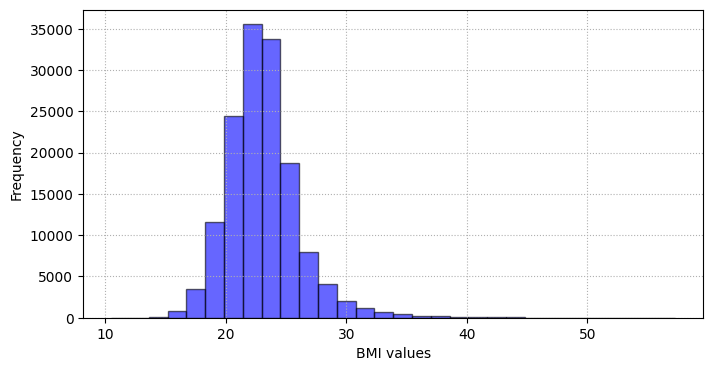

In [ ]:
# the histogram plot
plt.figure(figsize = (8,4))
bios['bmi'].plot(kind = 'hist', bins = 30, color = 'blue', alpha = 0.6, edgecolor = 'k')
plt.xlabel('BMI values')
plt.ylabel('Frequency')
plt.grid(axis = 'both', linestyle = 'dotted')
plt.show()
# here is the approximate distribution of BMI.
# in previous cell precise aggregation in done

## Which BMI ranges dominate professional athletes?

In [25]:
# top 5 precise values of BMI for athletes(in descending order)
bmi_counts.head()

bmi
23.148148    574
21.604938    501
22.857143    476
20.761246    468
22.093170    455
Name: count, dtype: int64

## Are extreme BMI values more common in specific eras?

> Extreme BMI values: thinness(<= 18.5) AND obese(>=35)

In [26]:
# first we'll define eras
# to define eras, we need to derive the decade in which each athlete was born
bios['born_datetime'] = pd.to_datetime(bios['born_date'])
bios.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,bmi,born_datetime
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,176.424041,72.286383,1960-10-02,23.224211,1886-12-12
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.000000,76.000000,NaN,22.694019,1969-04-01
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.000000,76.000000,1994-07-17,22.694019,1898-08-13
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.000000,64.000000,1978-03-20,22.675737,1895-05-11
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,174.500000,67.000000,1930-07-25,22.003103,1878-04-17


In [29]:
bios.insert(2,'born_decade', (bios['born_datetime'].dt.year // 10) * 10)
bios.head()

,athlete_id,name,born_decade,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,bmi,born_datetime
0,1,Jean-François Blanchy,1880.0,1886-12-12,Bordeaux,Gironde,FRA,France,176.424041,72.286383,1960-10-02,23.224211,1886-12-12
1,2,Arnaud Boetsch,1960.0,1969-04-01,Meulan,Yvelines,FRA,France,183.000000,76.000000,NaN,22.694019,1969-04-01
2,3,Jean Borotra,1890.0,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.000000,76.000000,1994-07-17,22.694019,1898-08-13
3,4,Jacques Brugnon,1890.0,1895-05-11,Paris VIIIe,Paris,FRA,France,168.000000,64.000000,1978-03-20,22.675737,1895-05-11
4,5,Albert Canet,1870.0,1878-04-17,Wandsworth,England,GBR,France,174.500000,67.000000,1930-07-25,22.003103,1878-04-17


In [30]:
# modern era athletes -> decade > 1900
# early era athletes -> decade <= 1900
modern_era = bios[bios['born_decade'] > 1900]
early_era = bios[bios['born_decade'] <= 1900]

In [34]:
# count of Extreme BMI's in Early era
extreme_BMI_early = early_era[(early_era['bmi'] >= 35) | (early_era['bmi']<= 18.5)]
extreme_BMI_early.shape[0]

206

In [35]:
# count of Extreme BMI's in Modern era
extreme_BMI_modern = modern_era[(modern_era['bmi'] >= 35) | (modern_era['bmi']<= 18.5)]
extreme_BMI_modern.shape[0]

5857

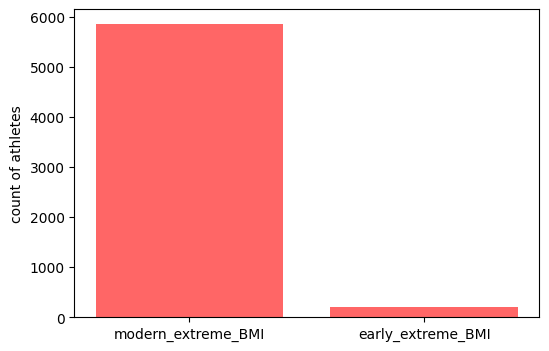

In [38]:
# plot of this
plt.figure(figsize = (6,4))
data = {
    'modern_extreme_BMI':extreme_BMI_modern.shape[0],
    'early_extreme_BMI':extreme_BMI_early.shape[0]
}
plt.bar(data.keys(), data.values(), color = 'red', alpha = 0.6)
plt.ylabel('count of athletes')
plt.show()

> modern era athletes have significantly higher number for extreme BMI

## Which countries have the widest BMI spread?

In [48]:
# using the 'range: max - min' for determining the diversity
bmi_range_by_country = bios.groupby('born_country')['bmi'].agg(['min','max'])
bmi_range_by_country['range'] = bmi_range_by_country['max'] - bmi_range_by_country['min']
bmi_range_by_country.sort_values('range', ascending=False)

,min,max,range
born_country,,,
POL,13.886134,57.282583,43.396449
RUS,14.532872,56.495351,41.962479
GBR,13.988334,53.238687,39.250353
USA,14.333065,51.789235,37.456170
ESP,12.500000,49.500000,37.000000
...,...,...,...
Elster,24.453568,24.453568,0.000000
GIB,24.396261,24.396261,0.000000
SEY,21.469150,21.469150,0.000000


> Poland has the highest diversity in terms of BMI

## Does BMI correlate better with weight or height?

In [49]:
p = bios['weight_kg'].values
q = bios['height_cm'].values
x = bios['bmi'].values

In [52]:
# weight correlation with BMI
print(np.corrcoef(p,x)[0, 1])

0.815307307473687


In [ ]:
# height correlation with BMI
print(np.corrcoef(q,x)[0, 1])

0.22836639866842387


In [54]:
# height squared correlation with BMI
q2 = bios['height_cm']**2
height_square = q2.values
print(np.corrcoef(height_square,x)[0, 1])

0.22665359889239614


> Weight correlated significanly better with BMI unlike height and height_square